# ================================================================
# ROLE CATEGORISATION EXPERIMENT (RAG) — ZERO-SHOT PROMPTING
# ================================================================

## Objective
This experiment evaluates the ability of a Large Language Model (LLM) to classify job descriptions into predefined role categories using zero-shot prompting with Retrieval-Augmented Generation (RAG).

## Dataset
- Source: Djinni Job Descriptions Dataset
- Sample size: 100 job descriptions
- Columns used:
  - Long Description
  - Position
  - Primary Keyword
  - id
  - standard_role

## Role Taxonomy
A fixed taxonomy is used for classification.
This taxonomy is stored in:
- role_taxonomy.csv

Each job description must be classified into exactly one of the predefined roles:
Backend Developer, Frontend Developer, Full Stack Developer, DevOps Engineer,
Data / AI Role, QA Engineer, Mobile Developer, Software Engineer,
Project / Program Manager, Product Manager, Marketing / Sales,
Business / Operations Role, Design / Creative Role, Other

## RAG Configuration
- RAG Setting: With RAG
- Input: Job Description + Retrieved Context
- Output: One role label from taxonomy
- Chunk Size: 150 words
- Chunk Overlap: 30 words
- Embedding Model: sentence-transformers/all-MiniLM-L6-v2
- Vector Database: ChromaDB
- Retrieval Method: Dense vector retrieval
- Similarity Metric: Cosine similarity
- Top-K: 5

## Experimental Setup
- Approach: Zero-Shot Prompting with RAG
- Model: llama-3.3-70b-versatile (Groq)
- Temperature: 0.0
- Max Tokens: 700
- Label Set: Fixed predefined roles

## Methodology
1. Load dataset with standardized roles
2. Clean and preprocess job descriptions
3. Split each job description into chunks of 400 words with 50-word overlap
4. Generate chunk embeddings using all-MiniLM-L6-v2
5. Store chunk embeddings and metadata in ChromaDB
6. Retrieve Top-5 relevant chunks using cosine similarity
7. Merge retrieved chunks into contextual input
8. Build zero-shot prompt with role taxonomy and retrieved context
9. Send prompt to LLM
10. Capture predicted label
11. Compare prediction with ground truth (standard_role)
12. Store results for all samples

## Evaluation Metrics
- Accuracy
- Precision (Macro)
- Recall (Macro)
- F1-score (Macro)
- Confusion Matrix

## Outputs
- results.csv
- results.json
- final_metrics.csv
- final_metrics.json
- confusion_matrix.csv
- confusion_matrix.png
- classification_report.csv
- retrieval_log.csv

## Purpose
This experiment evaluates whether adding retrieved job-description context improves role categorisation performance compared with the non-RAG baseline.
# ================================================================

In [1]:
# ================================================================
# INSTALL REQUIRED LIBRARIES
# ================================================================
!pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm groq tenacity sentence-transformers chromadb

print("=" * 60)
print("Required libraries installed")
print("=" * 60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not curre

LIBRARY VERSION CHECK
pandas               : 2.2.2
numpy                : 2.0.2
scikit-learn         : 1.6.1
sentence-transformers: 5.4.1
chromadb             : 1.5.9
groq                 : 1.2.0
tenacity             : 9.1.4
Mounted at /content/drive
Project directory: /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis
Number of Groq API keys loaded: 3
EXPERIMENT CONFIGURATION
Experiment ID       : exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile
Task                : role_categorization
Prompt type         : zero_shot_with_rag
Model               : llama-3.3-70b-versatile
Temperature         : 0.0
Max tokens          : 700
Embedding model     : all-MiniLM-L6-v2
Chunk size words    : 150
Chunk overlap words : 30
Top-K retrieval     : 5
Input               : Retrieved JD chunks
RAG                 : Yes
Run sample size     : None
Dataset path        : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/data/role_labels/djinni_with_standardized_roles.csv
Tax

,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,index_level_0,Reference_Summary,position_normalized,standard_role
0,Java Developer,The job holder will . Design develop and maint...,Quickstarter,3y,Java,upper,2021-12-01T00:00:00+02:00,en,67aefec1-1efc-5c5b-b2db-c0ef5b74f519,77261,Role Overview:\nThe Java Developer will design...,java developer,Backend Developer
1,Integration specialist / DevOps,Project Description Join our Development Cente...,Luxoft,3y,DevOps,upper,2022-04-01T00:00:00+03:00,en,2ec599d6-1509-5c34-9aec-54ac2e04b2d5,72279,Role Overview:\nThe Integration Specialist / D...,integration specialist devops,DevOps Engineer
2,Head of Marketing,TurnKey Labs is the most trusted offshore soft...,TurnKey Labs,5y,Marketing,upper,2021-10-01T00:00:00+03:00,en,edba8bfd-8a91-5b37-9f72-bde92397e804,69706,"Role Overview:\nReporting to the CEO, the Head...",head of marketing,Marketing / Sales


Role taxonomy preview


,role_id,standard_role,description,example_keywords
0,ROLE_01,Backend Developer,Server-side development roles involving backen...,"backend, java, spring, python developer, node...."
1,ROLE_02,Frontend Developer,Client-side development roles involving web UI...,"frontend, front-end, react, angular, vue, java..."
2,ROLE_03,Full Stack Developer,Roles requiring both frontend and backend deve...,"full stack, full-stack, fullstack, mern, mean"
3,ROLE_04,DevOps Engineer,"Infrastructure, CI/CD, cloud, deployment, auto...","devops, cloud, aws, azure, gcp, kubernetes, do..."
4,ROLE_05,Data / AI Role,"Data science, data engineering, machine learni...","data scientist, data engineer, machine learnin..."
5,ROLE_06,QA Engineer,"Software testing, quality assurance, automatio...","qa, quality assurance, tester, test engineer, ..."
6,ROLE_07,Mobile Developer,Mobile application development roles involving...,"android, ios, mobile, flutter, react native, k..."
7,ROLE_08,Project / Program Manager,"Project management, delivery management, scrum...","project manager, program manager, delivery man..."
8,ROLE_09,Product Manager,"Product ownership, product strategy, product m...","product manager, product owner, product lead"
9,ROLE_10,Marketing / Sales,"Marketing, sales, business development, custom...","marketing, sales, business development, growth..."


REQUIRED COLUMN VALIDATION
FOUND: id
FOUND: Long Description
FOUND: Position
FOUND: Primary Keyword
FOUND: standard_role
DATA CLEANING SUMMARY
Original rows          : 100
Rows after cleaning    : 100
Rows removed           : 0
Duplicate removal      : Applied on Long Description
Minimum JD word count  : 30


...

,experiment_id,task_name,prompt_type,model_name,temperature,max_tokens,rag_used,input_type,embedding_model,chunk_size_words,...,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,avg_retrieved_chunks,avg_top_similarity,num_taxonomy_labels
0,exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile,role_categorization,zero_shot_with_rag,llama-3.3-70b-versatile,0.0,700,True,retrieved_job_description_chunks,all-MiniLM-L6-v2,150,...,0.75,0.7582,0.8219,0.7577,0.7649,0.75,0.7254,2.27,0.955,13


FINAL CHUNK STATISTICS
Average chunks created per JD : 2.29
Minimum chunks created per JD : 1
Maximum chunks created per JD : 6
Average chunks retrieved      : 2.27
Minimum chunks retrieved      : 1
Maximum chunks retrieved      : 5
CLASSIFICATION REPORT SAVED
Saved file: /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/with_rag/exp_47/classification_report.csv


,label,precision,recall,f1-score,support
0,Backend Developer,0.714286,0.789474,0.750000,19.00
1,Frontend Developer,1.000000,0.750000,0.857143,8.00
2,Full Stack Developer,0.545455,1.000000,0.705882,6.00
3,DevOps Engineer,0.777778,0.875000,0.823529,8.00
4,Data / AI Role,0.750000,1.000000,0.857143,3.00
5,QA Engineer,0.700000,1.000000,0.823529,7.00
6,Mobile Developer,1.000000,0.750000,0.857143,4.00
7,Project / Program Manager,0.750000,1.000000,0.857143,3.00
8,Product Manager,0.500000,1.000000,0.666667,1.00
9,Marketing / Sales,0.777778,0.700000,0.736842,10.00


CONFUSION MATRIX


,Backend Developer,Frontend Developer,Full Stack Developer,DevOps Engineer,Data / AI Role,QA Engineer,Mobile Developer,Project / Program Manager,Product Manager,Marketing / Sales,Business / Operations Role,Design / Creative Role,Other
Backend Developer,15,0,2,0,1,1,0,0,0,0,0,0,0
Frontend Developer,1,6,1,0,0,0,0,0,0,0,0,0,0
Full Stack Developer,0,0,6,0,0,0,0,0,0,0,0,0,0
DevOps Engineer,1,0,0,7,0,0,0,0,0,0,0,0,0
Data / AI Role,0,0,0,0,3,0,0,0,0,0,0,0,0
QA Engineer,0,0,0,0,0,7,0,0,0,0,0,0,0
Mobile Developer,0,0,0,0,0,0,3,0,1,0,0,0,0
Project / Program Manager,0,0,0,0,0,0,0,3,0,0,0,0,0
Product Manager,0,0,0,0,0,0,0,0,1,0,0,0,0
Marketing / Sales,0,0,2,0,0,0,0,0,0,7,0,1,0


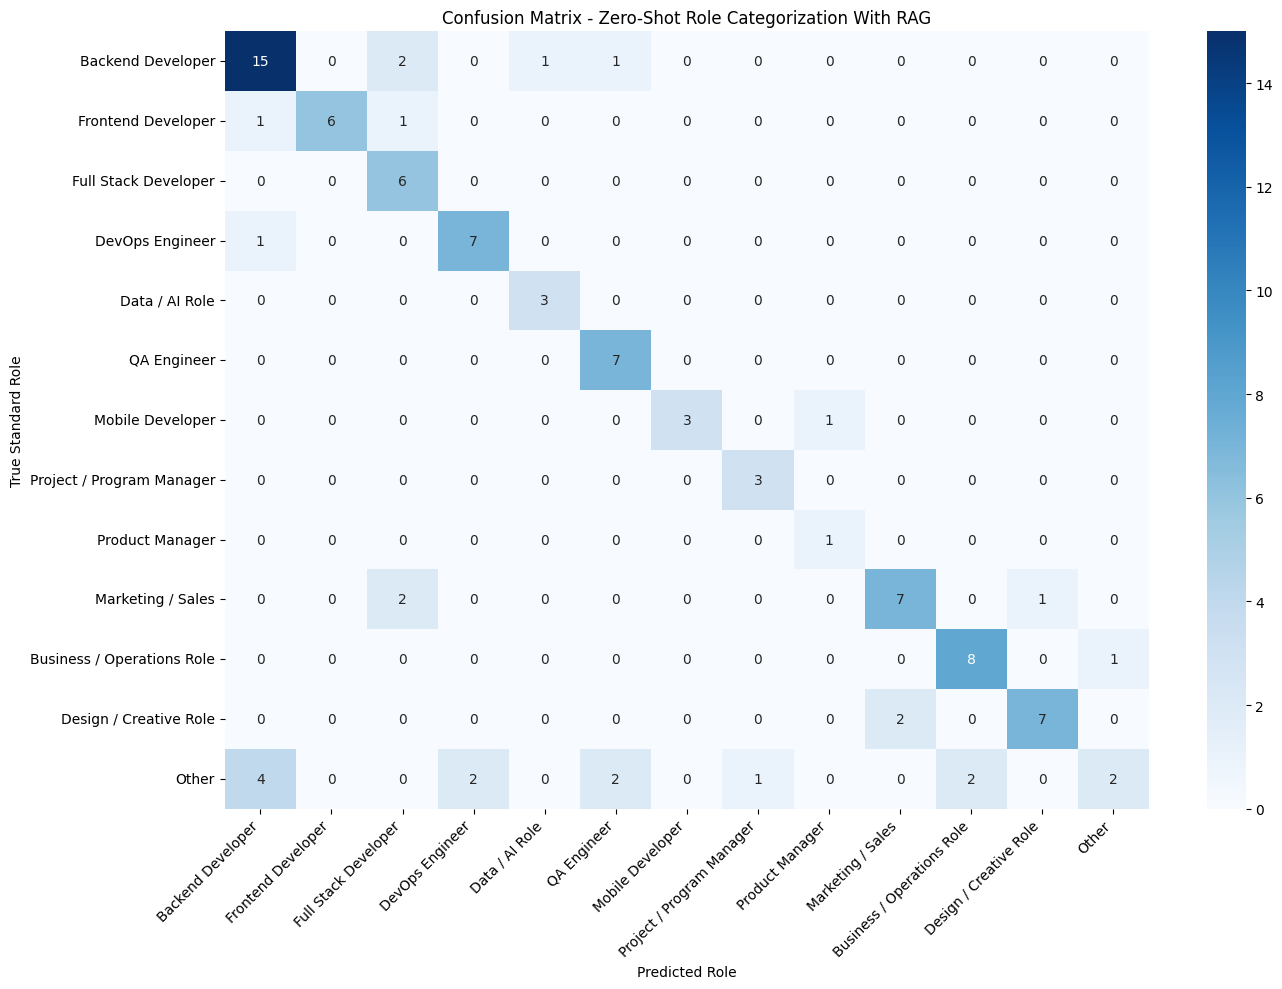

Saved confusion matrix CSV: /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/with_rag/exp_47/confusion_matrix.csv
Saved confusion matrix PNG: /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/with_rag/exp_47/confusion_matrix.png
ERROR ANALYSIS
Total incorrect predictions: 25


,selected_id,position,primary_keyword,standard_role,predicted_role,raw_prediction,retrieved_chunk_indices,retrieved_similarities
13,345fde08-2c9b-51b6-aaef-e0d10cbe15b0,Junior Salesforce Developer,JavaScript,Marketing / Sales,Full Stack Developer,Full Stack Developer,"[0, 1]","[0.9836, 0.4611]"
15,1033d838-1753-5d48-8a93-3981e34666f6,Analyst Relations Manager,Business Analyst,Other,Business / Operations Role,Business / Operations Role,"[0, 1]","[0.958, 0.7324]"
17,03d5d9fe-f19b-5baa-9f80-29d3bf3cd9c7,WFM Real Time Analyst,Other,Other,Business / Operations Role,Business / Operations Role,"[0, 1, 2, 3]","[0.9604, 0.7702, 0.4929, 0.3518]"
20,9b343996-ce39-56ad-bed1-ccb5a41814fc,Product Manager iOS,Product Manager,Mobile Developer,Product Manager,Product Manager,[0],[1.0]
21,66a7dbc2-c188-5afa-a2fa-f729ef2292b2,Performance Engineer (Python),Python,Other,DevOps Engineer,DevOps Engineer,"[0, 1, 2]","[0.8564, 0.7815, 0.3224]"
24,cc8a84c0-8df5-5e44-9793-50991b3e46e2,Front-end Developer React,JavaScript,Frontend Developer,Full Stack Developer,Full Stack Developer,[0],[1.0]
30,faa0d662-bb50-5bed-b5e4-eda682b0fa93,Engineering Manager (Digital Lead),Lead,Other,Project / Program Manager,Project / Program Manager,"[0, 1, 2]","[0.9645, 0.7606, 0.6222]"
32,28026ee0-ae44-5a81-b89a-b10a92b18de2,Exceptional Storyteller (Senior Marketeer),Marketing,Design / Creative Role,Marketing / Sales,Marketing / Sales,"[0, 1, 2, 3, 4]","[0.9584, 0.8186, 0.6829, 0.6134, 0.6094]"
37,5c276aed-16cf-558a-9363-37ebe181c462,.Net Lead Software Engineer,.NET,Backend Developer,Full Stack Developer,Full Stack Developer,"[0, 1, 4, 3, 2]","[0.9404, 0.76, 0.6694, 0.6357, 0.6196]"
38,6d52ffe8-e7ac-5548-9aae-5b905a224208,Intern С# Developer,.NET,Other,Backend Developer,Backend Developer,[0],[1.0]


RETRIEVAL ANALYSIS
Retrieval log rows: 100


,experiment_id,selected_id,num_retrieved_chunks,retrieved_chunk_indices,retrieved_similarities,num_chunks_created,top_similarity
0,exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile,67aefec1-1efc-5c5b-b2db-c0ef5b74f519,1,[0],[1.0],1,1.0000
1,exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile,2ec599d6-1509-5c34-9aec-54ac2e04b2d5,2,"[0, 1]","[0.8755, 0.7959]",2,0.8755
2,exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile,edba8bfd-8a91-5b37-9f72-bde92397e804,5,"[0, 1, 2, 3, 4]","[0.9408, 0.8666, 0.6431, 0.5365, 0.4605]",5,0.9408
3,exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile,077025bf-2c32-5855-9211-68b09228a635,2,"[0, 1]","[0.8869, 0.7888]",2,0.8869
4,exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile,adb62bd6-998e-58ec-a32c-3b99fe814b04,1,[0],[1.0],1,1.0000
5,exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile,b2315b02-ac50-551c-93b5-a88d6ee230e6,2,"[0, 1]","[0.9835, 0.4108]",2,0.9835
6,exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile,881421a8-07a9-59a0-9765-6c48609ae879,2,"[0, 1]","[0.9709, 0.7543]",2,0.9709
7,exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile,b5fc4457-65a2-51c9-92fe-b9be2fc4888c,3,"[0, 1, 2]","[0.906, 0.6458, 0.2475]",3,0.9060
8,exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile,bcbb5ce1-9ab8-5297-9472-791398c09e55,2,"[0, 1]","[0.974, 0.5913]",2,0.9740
9,exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile,16fcc7e5-ba83-5125-92eb-3e9cc3185261,4,"[0, 1, 2, 3]","[0.9134, 0.794, 0.5552, 0.5217]",4,0.9134


Average top similarity: 0.955
Minimum top similarity: 0.828
Maximum top similarity: 1.0
FINAL OUTPUT FILES
1. Results CSV             : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/with_rag/exp_47/results.csv
2. Results JSON            : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/with_rag/exp_47/results.json
3. Final metrics CSV       : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/with_rag/exp_47/final_metrics.csv
4. Final metrics JSON      : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/with_rag/exp_47/final_metrics.json
5. Confusion matrix CSV    : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/with_rag/exp_47/confusion_matrix.csv
6. Confusion matrix PNG    : /content/drive/MyDriv

,Backend Developer,Frontend Developer,Full Stack Developer,DevOps Engineer,Data / AI Role,QA Engineer,Mobile Developer,Project / Program Manager,Product Manager,Marketing / Sales,Business / Operations Role,Design / Creative Role,Other
Backend Developer,15,0,2,0,1,1,0,0,0,0,0,0,0
Frontend Developer,1,6,1,0,0,0,0,0,0,0,0,0,0
Full Stack Developer,0,0,6,0,0,0,0,0,0,0,0,0,0
DevOps Engineer,1,0,0,7,0,0,0,0,0,0,0,0,0
Data / AI Role,0,0,0,0,3,0,0,0,0,0,0,0,0
QA Engineer,0,0,0,0,0,7,0,0,0,0,0,0,0
Mobile Developer,0,0,0,0,0,0,3,0,1,0,0,0,0
Project / Program Manager,0,0,0,0,0,0,0,3,0,0,0,0,0
Product Manager,0,0,0,0,0,0,0,0,1,0,0,0,0
Marketing / Sales,0,0,2,0,0,0,0,0,0,7,0,1,0


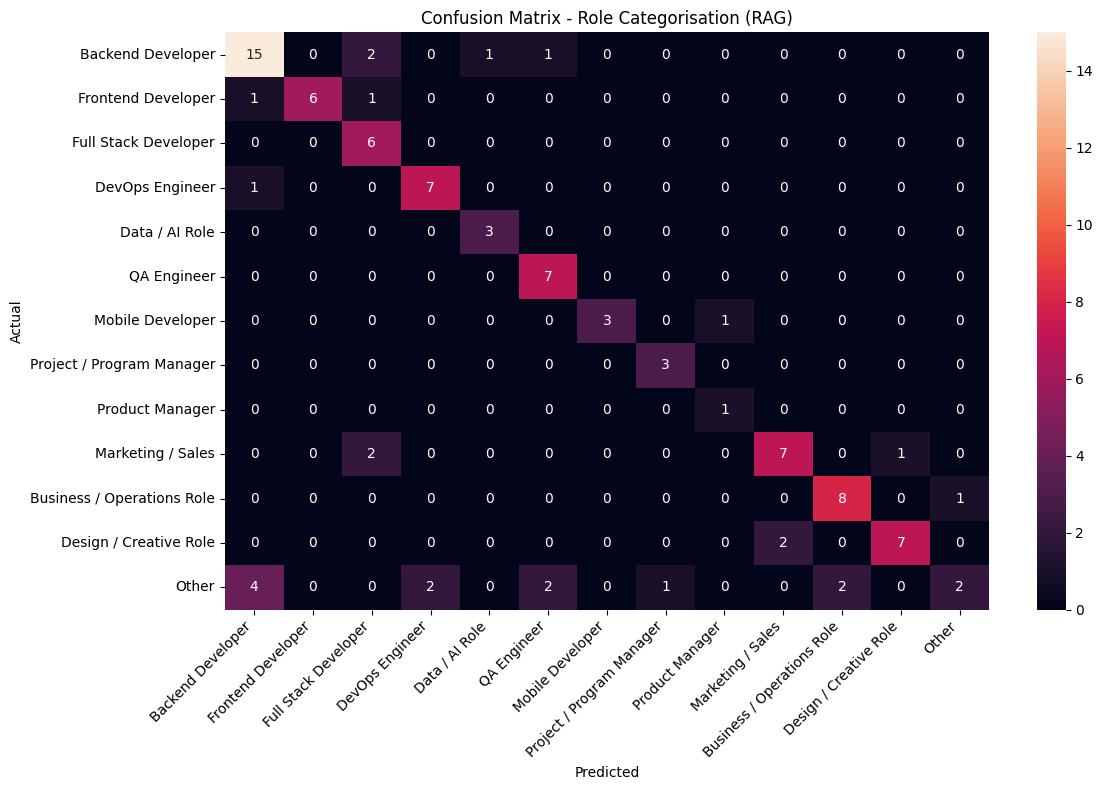

In [2]:
# ================================================================
# 1. BASIC PYTHON LIBRARIES
# ================================================================
import os
import re
import json
import time
import random
import shutil
import warnings
import importlib.metadata
from pathlib import Path

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ================================================================
# 2. ML / EVALUATION LIBRARIES
# ================================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# 3. RAG / EMBEDDING LIBRARIES
# ================================================================
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings

# ================================================================
# 4. LLM LIBRARIES
# ================================================================
from groq import Groq, RateLimitError, AuthenticationError, APIError
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

# ================================================================
# 5. GOOGLE COLAB / DRIVE
# ================================================================
from google.colab import drive, userdata

# ================================================================
# 6. VERSION CHECKS
# ================================================================
def get_version(pkg):
    try:
        return importlib.metadata.version(pkg)
    except Exception:
        return "installed"


print("=" * 60)
print("LIBRARY VERSION CHECK")
print("=" * 60)
print("pandas               :", pd.__version__)
print("numpy                :", np.__version__)
print("scikit-learn         :", get_version("scikit-learn"))
print("sentence-transformers:", get_version("sentence-transformers"))
print("chromadb             :", get_version("chromadb"))
print("groq                 :", get_version("groq"))
print("tenacity             :", get_version("tenacity"))
print("=" * 60)

# ================================================================
# 7. MOUNT GOOGLE DRIVE
# ================================================================
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)

# ================================================================
# 8. LOAD GROQ API KEY
# ================================================================
GROQ_API_KEYS = [
    userdata.get("GROQ_API_KEY_3"),
    userdata.get("GROQ_API_KEY_4"),
    userdata.get("GROQ_API_KEY_5"),
]

GROQ_API_KEYS = [key for key in GROQ_API_KEYS if key]

if not GROQ_API_KEYS:
    raise ValueError("No Groq API keys found in Colab Secrets.")

print("Number of Groq API keys loaded:", len(GROQ_API_KEYS))

# ================================================================
# 9. EXPERIMENT CONFIGURATION
# ================================================================

# -----------------------------
# Dataset paths
# -----------------------------
ROLE_LABEL_DATA_DIR = PROJECT_DIR / "data" / "role_labels"

STANDARDIZED_DATASET_PATH = ROLE_LABEL_DATA_DIR / "djinni_with_standardized_roles.csv"
ROLE_TAXONOMY_PATH = ROLE_LABEL_DATA_DIR / "role_taxonomy.csv"

# -----------------------------
# Required columns
# -----------------------------
TEXT_COLUMN = "Long Description"
ID_COLUMN = "id"
POSITION_COLUMN = "Position"
PRIMARY_KEYWORD_COLUMN = "Primary Keyword"
STANDARD_ROLE_COLUMN = "standard_role"

# -----------------------------
# Experiment metadata
# -----------------------------
EXPERIMENT_ID = "exp_47_rc_zero_shot_rag_llama-3.3-70b-versatile"
TASK_NAME = "role_categorization"
PROMPT_TYPE = "zero_shot_with_rag"
MODEL_NAME = "llama-3.3-70b-versatile"
OUTPUT_FOLDER_NAME = "exp_47"

TEMPERATURE = 0.0
MAX_TOKENS = 700

# For testing, set RUN_SAMPLE_SIZE = 10
# For final run, set RUN_SAMPLE_SIZE = None
RUN_SAMPLE_SIZE = None

# -----------------------------
# RAG configuration
# -----------------------------
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
CHUNK_SIZE_WORDS = 150
CHUNK_OVERLAP_WORDS = 30
TOP_K = 5

# -----------------------------
# Output paths
# -----------------------------
OUTPUT_DIR = (
    PROJECT_DIR
    / "outputs"
    / "experiments"
    / "role_categorization"
    / "with_rag"
    / OUTPUT_FOLDER_NAME
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = OUTPUT_DIR / "results.csv"
RESULTS_JSON = OUTPUT_DIR / "results.json"

FAILED_RESULTS_CSV = OUTPUT_DIR / "failed_results.csv"

FINAL_METRICS_CSV = OUTPUT_DIR / "final_metrics.csv"
FINAL_METRICS_JSON = OUTPUT_DIR / "final_metrics.json"

CONFUSION_MATRIX_CSV = OUTPUT_DIR / "confusion_matrix.csv"
CONFUSION_MATRIX_PNG = OUTPUT_DIR / "confusion_matrix.png"

CLASSIFICATION_REPORT_CSV = OUTPUT_DIR / "classification_report.csv"

RETRIEVAL_LOG_CSV = OUTPUT_DIR / "retrieval_log.csv"

CHROMA_DIR = OUTPUT_DIR / "chroma_db"
CHROMA_COLLECTION_NAME = "djinni_role_categorization_chunks"

print("=" * 60)
print("EXPERIMENT CONFIGURATION")
print("=" * 60)
print("Experiment ID       :", EXPERIMENT_ID)
print("Task                :", TASK_NAME)
print("Prompt type         :", PROMPT_TYPE)
print("Model               :", MODEL_NAME)
print("Temperature         :", TEMPERATURE)
print("Max tokens          :", MAX_TOKENS)
print("Embedding model     :", EMBEDDING_MODEL_NAME)
print("Chunk size words    :", CHUNK_SIZE_WORDS)
print("Chunk overlap words :", CHUNK_OVERLAP_WORDS)
print("Top-K retrieval     :", TOP_K)
print("Input               : Retrieved JD chunks")
print("RAG                 : Yes")
print("Run sample size     :", RUN_SAMPLE_SIZE)
print("Dataset path        :", STANDARDIZED_DATASET_PATH)
print("Taxonomy path       :", ROLE_TAXONOMY_PATH)
print("Output dir          :", OUTPUT_DIR)
print("Chroma dir          :", CHROMA_DIR)
print("=" * 60)

# ================================================================
# 10. LOAD STANDARDIZED DATASET AND ROLE TAXONOMY
# ================================================================
print("=" * 60)
print("Loading standardized Djinni dataset and role taxonomy...")
print("=" * 60)

if not STANDARDIZED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Standardized dataset not found: {STANDARDIZED_DATASET_PATH}")

if not ROLE_TAXONOMY_PATH.exists():
    raise FileNotFoundError(f"Role taxonomy file not found: {ROLE_TAXONOMY_PATH}")

df = pd.read_csv(STANDARDIZED_DATASET_PATH)
taxonomy_df = pd.read_csv(ROLE_TAXONOMY_PATH)

print("Dataset loaded successfully")
print("Dataset shape :", df.shape)
print("Dataset columns:", list(df.columns))

print("\nRole taxonomy loaded successfully")
print("Taxonomy shape :", taxonomy_df.shape)
print("Taxonomy columns:", list(taxonomy_df.columns))

print("=" * 60)
print("Dataset preview")
print("=" * 60)
display(df.head(3))

print("=" * 60)
print("Role taxonomy preview")
print("=" * 60)
display(taxonomy_df)

# ================================================================
# 11. VALIDATE REQUIRED COLUMNS
# ================================================================
required_columns = [
    ID_COLUMN,
    TEXT_COLUMN,
    POSITION_COLUMN,
    PRIMARY_KEYWORD_COLUMN,
    STANDARD_ROLE_COLUMN
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("=" * 60)
print("REQUIRED COLUMN VALIDATION")
print("=" * 60)

for col in required_columns:
    print(f"FOUND: {col}")

print("=" * 60)

# ================================================================
# 12. DATA CLEANING / PREPROCESSING
# ================================================================
def clean_text(text: str) -> str:
    """
    Cleans job description text.
    Removes HTML tags, URLs, excessive whitespace, and noisy characters.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def preprocess_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Selects required fields, removes null records, cleans text,
    removes duplicate job descriptions, and removes noisy short records.
    """
    work_df = df[
        [
            ID_COLUMN,
            TEXT_COLUMN,
            POSITION_COLUMN,
            PRIMARY_KEYWORD_COLUMN,
            STANDARD_ROLE_COLUMN
        ]
    ].copy()

    original_count = len(work_df)

    work_df = work_df.dropna(
        subset=[
            ID_COLUMN,
            TEXT_COLUMN,
            POSITION_COLUMN,
            STANDARD_ROLE_COLUMN
        ]
    )

    work_df[TEXT_COLUMN] = work_df[TEXT_COLUMN].apply(clean_text)

    work_df = work_df[work_df[TEXT_COLUMN].str.strip().ne("")]

    work_df["jd_word_count"] = work_df[TEXT_COLUMN].apply(lambda x: len(str(x).split()))
    work_df = work_df[work_df["jd_word_count"] >= 30]

    work_df = work_df.drop_duplicates(subset=[TEXT_COLUMN]).reset_index(drop=True)

    cleaned_count = len(work_df)

    print("=" * 60)
    print("DATA CLEANING SUMMARY")
    print("=" * 60)
    print("Original rows          :", original_count)
    print("Rows after cleaning    :", cleaned_count)
    print("Rows removed           :", original_count - cleaned_count)
    print("Duplicate removal      : Applied on Long Description")
    print("Minimum JD word count  : 30")
    print("=" * 60)

    return work_df


clean_df = preprocess_dataset(df)

display(clean_df.head(3))

# ================================================================
# 13. VALIDATE ROLE LABELS AGAINST TAXONOMY
# ================================================================
ROLE_LABELS = taxonomy_df["standard_role"].dropna().astype(str).tolist()

dataset_roles = sorted(clean_df[STANDARD_ROLE_COLUMN].dropna().unique().tolist())
taxonomy_roles = sorted(ROLE_LABELS)

unknown_roles = sorted(set(dataset_roles) - set(taxonomy_roles))

if unknown_roles:
    raise ValueError(f"Dataset contains roles not present in taxonomy: {unknown_roles}")

print("=" * 60)
print("ROLE LABEL VALIDATION")
print("=" * 60)
print("Number of taxonomy labels :", len(ROLE_LABELS))
print("Dataset role labels       :", len(dataset_roles))
print("\nRole labels:")
for role in ROLE_LABELS:
    print("-", role)
print("=" * 60)

role_distribution = (
    clean_df[STANDARD_ROLE_COLUMN]
    .value_counts()
    .reset_index()
)

role_distribution.columns = ["standard_role", "count"]
role_distribution["percentage"] = round(role_distribution["count"] / len(clean_df) * 100, 2)

display(role_distribution)

# ================================================================
# 14. SELECT EXPERIMENT SUBSET
# ================================================================
if RUN_SAMPLE_SIZE is not None:
    experiment_df = clean_df.head(RUN_SAMPLE_SIZE).copy().reset_index(drop=True)
else:
    experiment_df = clean_df.copy().reset_index(drop=True)

print("=" * 60)
print("EXPERIMENT DATASET")
print("=" * 60)
print("Total cleaned rows     :", len(clean_df))
print("Experiment rows        :", len(experiment_df))
print("Run sample size        :", RUN_SAMPLE_SIZE)
print("=" * 60)

display(
    experiment_df[
        [
            ID_COLUMN,
            POSITION_COLUMN,
            PRIMARY_KEYWORD_COLUMN,
            STANDARD_ROLE_COLUMN
        ]
    ].head(10)
)


# ================================================================
# 15. SELECT ONE JD USING ID FOR SANITY TEST
# ================================================================
SAMPLE_ID = str(experiment_df.loc[0, ID_COLUMN])

sample_row = experiment_df[experiment_df[ID_COLUMN].astype(str) == SAMPLE_ID]

if sample_row.empty:
    raise ValueError(f"No JD found for id: {SAMPLE_ID}")

sample_row = sample_row.iloc[0]

print("=" * 60)
print("SINGLE JD SANITY CHECK")
print("=" * 60)
print("Selected ID       :", sample_row[ID_COLUMN])
print("Position          :", sample_row[POSITION_COLUMN])
print("Primary Keyword   :", sample_row[PRIMARY_KEYWORD_COLUMN])
print("Standard Role     :", sample_row[STANDARD_ROLE_COLUMN])
print("JD preview        :", sample_row[TEXT_COLUMN][:500])
print("=" * 60)

# ================================================================
# 16. CHUNKING FUNCTIONS
# ================================================================
def split_text_into_word_chunks(
    text: str,
    chunk_size_words: int = 400,
    overlap_words: int = 50
):
    """
    Splits a job description into word-based chunks with overlap.
    """
    words = str(text).split()

    if len(words) == 0:
        return []

    if len(words) <= chunk_size_words:
        return [" ".join(words)]

    chunks = []
    start = 0

    while start < len(words):
        end = start + chunk_size_words
        chunk_words = words[start:end]
        chunk_text = " ".join(chunk_words)

        if chunk_text.strip():
            chunks.append(chunk_text)

        if end >= len(words):
            break

        start = end - overlap_words

    return chunks


sample_chunks = split_text_into_word_chunks(
    sample_row[TEXT_COLUMN],
    chunk_size_words=CHUNK_SIZE_WORDS,
    overlap_words=CHUNK_OVERLAP_WORDS
)

print("=" * 60)
print("CHUNKING SANITY CHECK")
print("=" * 60)
print("Selected ID      :", sample_row[ID_COLUMN])
print("JD word count    :", len(str(sample_row[TEXT_COLUMN]).split()))
print("Number of chunks :", len(sample_chunks))
print("Chunk size words :", CHUNK_SIZE_WORDS)
print("Overlap words    :", CHUNK_OVERLAP_WORDS)
print("=" * 60)

for idx, chunk in enumerate(sample_chunks[:3]):
    print(f"\nChunk {idx + 1} preview:")
    print(chunk[:700])


# ================================================================
# 17. LOAD EMBEDDING MODEL
# ================================================================
print("=" * 60)
print("Loading embedding model...")
print("=" * 60)

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

print("Embedding model loaded:", EMBEDDING_MODEL_NAME)
print("=" * 60)

# ================================================================
# 18. BUILD CHROMADB VECTOR STORE
# ================================================================
def reset_chroma_directory(chroma_dir: Path):
    """
    Deletes existing ChromaDB directory for a clean experiment run.
    """
    if chroma_dir.exists():
        shutil.rmtree(chroma_dir)

    chroma_dir.mkdir(parents=True, exist_ok=True)


def build_chroma_vector_store(
    experiment_df: pd.DataFrame,
    embedding_model,
    chroma_dir: Path,
    collection_name: str
):
    """
    Splits each JD into chunks, generates embeddings using all-MiniLM-L6-v2,
    and stores chunk embeddings with metadata in ChromaDB.
    """

    reset_chroma_directory(chroma_dir)

    chroma_client = chromadb.PersistentClient(
        path=str(chroma_dir),
        settings=Settings(anonymized_telemetry=False)
    )

    collection = chroma_client.get_or_create_collection(
        name=collection_name,
        metadata={"hnsw:space": "cosine"}
    )

    chunk_ids = []
    chunk_texts = []
    chunk_metadatas = []
    jd_chunk_count = {}

    print("=" * 60)
    print("CREATING JD CHUNKS")
    print("=" * 60)

    for _, row in tqdm(
        experiment_df.iterrows(),
        total=len(experiment_df),
        desc="Chunking JDs",
        unit="JD"
    ):
        selected_id = str(row[ID_COLUMN])
        jd_text = row[TEXT_COLUMN]

        chunks = split_text_into_word_chunks(
            jd_text,
            chunk_size_words=CHUNK_SIZE_WORDS,
            overlap_words=CHUNK_OVERLAP_WORDS
        )

        jd_chunk_count[selected_id] = len(chunks)

        tqdm.write(
            f"ID: {selected_id} | JD word count: {len(str(jd_text).split())} | "
            f"Chunks created: {len(chunks)}"
        )

        for chunk_index, chunk_text in enumerate(chunks):
            chunk_id = f"{selected_id}_chunk_{chunk_index}"

            metadata = {
                "selected_id": selected_id,
                "chunk_index": chunk_index,
                "position": str(row[POSITION_COLUMN]),
                "primary_keyword": str(row[PRIMARY_KEYWORD_COLUMN]),
                "standard_role": str(row[STANDARD_ROLE_COLUMN]),
                "chunk_word_count": len(chunk_text.split())
            }

            chunk_ids.append(chunk_id)
            chunk_texts.append(chunk_text)
            chunk_metadatas.append(metadata)

    print("Total chunks created:", len(chunk_texts))

    if len(chunk_texts) == 0:
        raise ValueError("No chunks created. Check dataset and cleaning logic.")

    print("=" * 60)
    print("GENERATING EMBEDDINGS")
    print("=" * 60)

    embeddings = embedding_model.encode(
        chunk_texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    print("Embedding shape:", embeddings.shape)

    print("=" * 60)
    print("STORING CHUNKS IN CHROMADB")
    print("=" * 60)

    batch_size = 500

    for start in tqdm(
        range(0, len(chunk_texts), batch_size),
        desc="Adding chunks to ChromaDB",
        unit="batch"
    ):
        end = start + batch_size

        collection.add(
            ids=chunk_ids[start:end],
            documents=chunk_texts[start:end],
            embeddings=embeddings[start:end].tolist(),
            metadatas=chunk_metadatas[start:end]
        )

    print("ChromaDB collection created successfully")
    print("Collection count:", collection.count())
    print("=" * 60)

    return chroma_client, collection, jd_chunk_count


chroma_client, collection, jd_chunk_count = build_chroma_vector_store(
    experiment_df=experiment_df,
    embedding_model=embedding_model,
    chroma_dir=CHROMA_DIR,
    collection_name=CHROMA_COLLECTION_NAME
)

# ================================================================
# 18A. CHUNKS CREATED SUMMARY
# ================================================================
print("=" * 60)
print("CHUNKS CREATED PER JD")
print("=" * 60)

for selected_id, count in list(jd_chunk_count.items())[:20]:
    print(f"ID: {selected_id} | Chunks created: {count}")

print("=" * 60)
print("Total JDs chunked       :", len(jd_chunk_count))
print("Total chunks created    :", sum(jd_chunk_count.values()))
print("Average chunks per JD   :", round(np.mean(list(jd_chunk_count.values())), 2))
print("Minimum chunks per JD   :", min(jd_chunk_count.values()))
print("Maximum chunks per JD   :", max(jd_chunk_count.values()))
print("=" * 60)

# ================================================================
# 19. RETRIEVAL FUNCTION
# ================================================================
def retrieve_top_k_chunks(
    query_text: str,
    selected_id: str,
    embedding_model,
    collection,
    top_k: int = 5
):
    """
    Retrieves Top-K relevant chunks for a selected JD using cosine similarity.
    Retrieval is restricted to chunks belonging to the same JD id.
    """

    query_embedding = embedding_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True
    )[0]

    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=top_k,
        where={"selected_id": str(selected_id)},
        include=["documents", "metadatas", "distances"]
    )

    retrieved_chunks = []

    docs = results.get("documents", [[]])[0]
    metadatas = results.get("metadatas", [[]])[0]
    distances = results.get("distances", [[]])[0]

    for rank, (doc, metadata, distance) in enumerate(zip(docs, metadatas, distances), start=1):
        cosine_similarity_score = 1 - float(distance)

        retrieved_chunks.append(
            {
                "rank": rank,
                "chunk_text": doc,
                "metadata": metadata,
                "distance": float(distance),
                "cosine_similarity": cosine_similarity_score
            }
        )

    return retrieved_chunks


def merge_retrieved_chunks(retrieved_chunks):
    """
    Merges retrieved chunks into one contextual input for the prompt.
    """
    context_parts = []

    for item in retrieved_chunks:
        rank = item["rank"]
        chunk_text = item["chunk_text"]

        context_parts.append(
            f"[Retrieved Chunk {rank}]\n{chunk_text}"
        )

    return "\n\n".join(context_parts)


sample_retrieved_chunks = retrieve_top_k_chunks(
    query_text=sample_row[TEXT_COLUMN],
    selected_id=str(sample_row[ID_COLUMN]),
    embedding_model=embedding_model,
    collection=collection,
    top_k=TOP_K
)

sample_context = merge_retrieved_chunks(sample_retrieved_chunks)

print("=" * 60)
print("RETRIEVAL SANITY CHECK")
print("=" * 60)
print("Selected ID:", sample_row[ID_COLUMN])
print("Retrieved chunks:", len(sample_retrieved_chunks))
print("=" * 60)

for item in sample_retrieved_chunks:
    print(
        "Rank:",
        item["rank"],
        "| Chunk index:",
        item["metadata"]["chunk_index"],
        "| Similarity:",
        round(item["cosine_similarity"], 4)
    )

print("=" * 60)
print("Merged context preview")
print("=" * 60)
print(sample_context[:2500])


# ================================================================
# 20. ZERO-SHOT RAG ROLE CATEGORIZATION PROMPT
# ================================================================
def build_role_list(role_labels):
    """
    Converts taxonomy labels into a numbered list for inspection.
    """
    return "\n".join([f"{i+1}. {role}" for i, role in enumerate(role_labels)])


def build_zero_shot_rag_role_prompt(
    retrieved_context: str,
    position: str,
    primary_keyword: str,
    role_labels: list
) -> str:
    """
    Builds zero-shot RAG prompt for role categorization.
    The model must choose exactly one role from the predefined taxonomy.
    """

    role_list_text = "\n".join([f"- {role}" for role in role_labels])

    prompt = f"""
You are an expert HR role classification assistant.

Your task is to classify the given job description context into exactly ONE role.

The context below was retrieved using a RAG pipeline from the job description.

PREDEFINED ROLE TAXONOMY:
{role_list_text}

STRICT DECISION RULE:
- Choose exactly ONE label from the predefined taxonomy
- Use the retrieved job description context as the main evidence
- Position and Primary Keyword are supporting signals only
- If the job description clearly matches a role → choose it
- If it is ambiguous, mixed, unclear, or does not strongly match → choose "Other"

IMPORTANT:
- Do NOT create a new label
- Do NOT return multiple labels
- Do NOT explain your answer
- Do NOT guess
- Return ONLY the role label exactly as written in the taxonomy

POSITION:
{position}

PRIMARY KEYWORD:
{primary_keyword}

RETRIEVED JOB DESCRIPTION CONTEXT:
{retrieved_context}

FINAL ROLE LABEL:
""".strip()

    return prompt


sample_prompt = build_zero_shot_rag_role_prompt(
    retrieved_context=sample_context,
    position=sample_row[POSITION_COLUMN],
    primary_keyword=sample_row[PRIMARY_KEYWORD_COLUMN],
    role_labels=ROLE_LABELS
)

print("=" * 60)
print("SAMPLE ZERO-SHOT RAG PROMPT")
print("=" * 60)
print(sample_prompt[:3500])
print("=" * 60)


# ================================================================
# 21. GROQ CLIENT
# ================================================================
class LLMClientError(Exception):
    pass


class GroqRotatingClient:
    """
    Groq client with API key rotation.
    Rotates key when rate limit, token expiry, or authentication issue occurs.
    """

    def __init__(self, model_name: str, api_keys: list):
        self.model_name = model_name
        self.api_keys = api_keys
        self.current_key_index = 0
        self.client = self._create_client()

    def _create_client(self):
        return Groq(api_key=self.api_keys[self.current_key_index])

    def rotate_key(self):
        old_index = self.current_key_index

        self.current_key_index = (self.current_key_index + 1) % len(self.api_keys)
        self.client = self._create_client()

        print(
            f"Switching Groq API key: "
            f"{old_index + 1} -> {self.current_key_index + 1}"
        )

    def generate(
        self,
        prompt: str,
        temperature: float,
        max_tokens: int,
        max_key_rotations: int = None
    ) -> str:

        if max_key_rotations is None:
            max_key_rotations = len(self.api_keys)

        last_error = None

        for attempt in range(max_key_rotations):

            try:
                completion = self.client.chat.completions.create(
                    model=self.model_name,
                    messages=[
                        {
                            "role": "system",
                            "content": (
                                "You are a precise HR role classification assistant. "
                                "Return only one label from the provided taxonomy."
                            )
                        },
                        {
                            "role": "user",
                            "content": prompt
                        }
                    ],
                    temperature=temperature,
                    max_tokens=max_tokens
                )

                if not completion.choices:
                    raise LLMClientError("Groq returned no choices.")

                text = completion.choices[0].message.content

                if not text or not str(text).strip():
                    raise LLMClientError("Groq returned an empty response.")

                return str(text).strip()

            except (RateLimitError, AuthenticationError, APIError) as e:
                last_error = e

                print("=" * 60)
                print("Groq API issue detected")
                print("Current key index:", self.current_key_index + 1)
                print("Error:", str(e)[:500])
                print("Trying next API key...")
                print("=" * 60)

                self.rotate_key()
                time.sleep(2)

            except Exception as e:
                last_error = e

                print("=" * 60)
                print("Unexpected LLM error")
                print("Error:", str(e)[:500])
                print("=" * 60)

                self.rotate_key()
                time.sleep(2)

        raise LLMClientError(
            f"All Groq API keys failed. Last error: {last_error}"
        )


print("Initialising rotating Groq client...")
groq_client = GroqRotatingClient(
    model_name=MODEL_NAME,
    api_keys=GROQ_API_KEYS
)

print("Rotating Groq client ready:", MODEL_NAME)
print("=" * 60)

# ================================================================
# 22. PREDICTED LABEL CLEANING AND VALIDATION
# ================================================================
def normalize_label_text(text: str) -> str:
    """
    Normalizes LLM output for matching against taxonomy.
    """
    if pd.isna(text):
        return ""

    text = str(text).strip()

    text = text.replace("`", "").replace("*", "").strip()

    text = re.sub(r"^final role label\s*:\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^role\s*:\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^label\s*:\s*", "", text, flags=re.IGNORECASE)

    text = text.split("\n")[0].strip()

    text = re.sub(r"^\d+[\.\)]\s*", "", text).strip()

    return text


def validate_predicted_label(raw_prediction: str, role_labels: list):
    """
    Validates whether predicted label belongs to the fixed taxonomy.
    Invalid outputs are converted to Other.
    """

    cleaned = normalize_label_text(raw_prediction)

    if cleaned in role_labels:
        return cleaned, True

    lower_map = {role.lower(): role for role in role_labels}

    if cleaned.lower() in lower_map:
        return lower_map[cleaned.lower()], True

    return "Other", False


print("Prediction cleaning and validation functions ready")
print("=" * 60)

# ================================================================
# 23. SINGLE JD TEST
# ================================================================
print("=" * 60)
print("RUNNING SINGLE JD RAG TEST")
print("=" * 60)

test_retrieved_chunks = retrieve_top_k_chunks(
    query_text=sample_row[TEXT_COLUMN],
    selected_id=str(sample_row[ID_COLUMN]),
    embedding_model=embedding_model,
    collection=collection,
    top_k=TOP_K
)

test_context = merge_retrieved_chunks(test_retrieved_chunks)

test_prompt = build_zero_shot_rag_role_prompt(
    retrieved_context=test_context,
    position=sample_row[POSITION_COLUMN],
    primary_keyword=sample_row[PRIMARY_KEYWORD_COLUMN],
    role_labels=ROLE_LABELS
)

raw_prediction = groq_client.generate(
    prompt=test_prompt,
    temperature=TEMPERATURE,
    max_tokens=MAX_TOKENS
)

predicted_role, is_valid_label = validate_predicted_label(
    raw_prediction=raw_prediction,
    role_labels=ROLE_LABELS
)

print("Selected ID       :", sample_row[ID_COLUMN])
print("Position          :", sample_row[POSITION_COLUMN])
print("Primary Keyword   :", sample_row[PRIMARY_KEYWORD_COLUMN])
print("True standard_role:", sample_row[STANDARD_ROLE_COLUMN])
print("Retrieved chunks  :", len(test_retrieved_chunks))
print("Raw prediction    :", raw_prediction)
print("Predicted role    :", predicted_role)
print("Valid label       :", is_valid_label)
print("Correct prediction:", predicted_role == sample_row[STANDARD_ROLE_COLUMN])
print("=" * 60)


# ================================================================
# 24. CHECKPOINT / RESUME
# ================================================================
if RESULTS_JSON.exists():
    with open(RESULTS_JSON, "r", encoding="utf-8") as f:
        loaded_results = json.load(f)

    if isinstance(loaded_results, list):
        all_results = loaded_results
        completed_ids = {
            str(row["selected_id"])
            for row in all_results
            if "selected_id" in row
        }
    else:
        all_results = []
        completed_ids = set()
else:
    all_results = []
    completed_ids = set()


if FAILED_RESULTS_CSV.exists():
    try:
        failed_results = pd.read_csv(FAILED_RESULTS_CSV).to_dict(orient="records")
    except Exception:
        failed_results = []
else:
    failed_results = []


if RETRIEVAL_LOG_CSV.exists():
    try:
        retrieval_logs = pd.read_csv(RETRIEVAL_LOG_CSV).to_dict(orient="records")
    except Exception:
        retrieval_logs = []
else:
    retrieval_logs = []


print("=" * 60)
print("CHECKPOINT STATUS")
print("=" * 60)
print("Already completed:", len(completed_ids))
print("Already failed   :", len(failed_results))
print("Retrieval logs   :", len(retrieval_logs))
print("=" * 60)

# ================================================================
# 25. CHECKPOINT SAVE FUNCTION
# ================================================================
def save_checkpoints(all_results, failed_results, retrieval_logs):

    # CRITICAL FIX: ensure directory always exists
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # also ensure parent dirs of files
    RESULTS_JSON.parent.mkdir(parents=True, exist_ok=True)

    with open(RESULTS_JSON, "w", encoding="utf-8") as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)

    if all_results:
        pd.DataFrame(all_results).to_csv(
            RESULTS_CSV,
            index=False,
            encoding="utf-8"
        )

    if failed_results:
        pd.DataFrame(failed_results).to_csv(
            FAILED_RESULTS_CSV,
            index=False,
            encoding="utf-8"
        )

    if retrieval_logs:
        pd.DataFrame(retrieval_logs).to_csv(
            RETRIEVAL_LOG_CSV,
            index=False,
            encoding="utf-8"
        )

print("Checkpoint save function ready")
print("=" * 60)


# ================================================================
# 26. RUN ZERO-SHOT RAG ROLE CATEGORIZATION EXPERIMENT
# ================================================================
print("=" * 60)
print("RUNNING ZERO-SHOT ROLE CATEGORIZATION WITH RAG")
print("=" * 60)
print("Samples            :", len(experiment_df))
print("Model              :", MODEL_NAME)
print("Embedding model    :", EMBEDDING_MODEL_NAME)
print("Temperature        :", TEMPERATURE)
print("Max tokens         :", MAX_TOKENS)
print("Chunk size words   :", CHUNK_SIZE_WORDS)
print("Chunk overlap words:", CHUNK_OVERLAP_WORDS)
print("Top-K retrieval    :", TOP_K)
print("Input              : Retrieved JD chunks")
print("=" * 60)


for i, row in tqdm(
    experiment_df.iterrows(),
    total=len(experiment_df),
    desc="Running Zero-Shot RAG Role Categorization",
    unit="JD"
):
    current_id = str(row[ID_COLUMN])

    if current_id in completed_ids:
        tqdm.write(f"Skipped {i+1}/{len(experiment_df)} | ID: {current_id}")
        continue

    tqdm.write("=" * 60)
    tqdm.write(f"Running {i+1}/{len(experiment_df)} | ID: {current_id}")

    try:
        job_description = row[TEXT_COLUMN]
        position = row[POSITION_COLUMN]
        primary_keyword = row[PRIMARY_KEYWORD_COLUMN]
        true_role = row[STANDARD_ROLE_COLUMN]

        # 1. Retrieve Top-K chunks from ChromaDB
        retrieved_chunks = retrieve_top_k_chunks(
            query_text=job_description,
            selected_id=current_id,
            embedding_model=embedding_model,
            collection=collection,
            top_k=TOP_K
        )

        chunks_created_for_jd = jd_chunk_count.get(current_id, 0)
        num_retrieved_chunks = len(retrieved_chunks)

        tqdm.write(
            f"Chunks created: {chunks_created_for_jd} | "
            f"Chunks retrieved: {num_retrieved_chunks} | "
            f"Top similarity: "
            f"{round(retrieved_chunks[0]['cosine_similarity'], 4) if num_retrieved_chunks > 0 else 'NA'}"
        )

        # 2. Merge retrieved chunks into contextual input
        retrieved_context = merge_retrieved_chunks(retrieved_chunks)

        if not retrieved_context.strip():
            raise ValueError("Retrieved context is empty.")

        # 3. Save retrieval log
        retrieved_chunk_indices = [
            item["metadata"]["chunk_index"]
            for item in retrieved_chunks
        ]

        retrieved_similarities = [
            round(item["cosine_similarity"], 4)
            for item in retrieved_chunks
        ]

        retrieval_logs.append(
            {
                "experiment_id": EXPERIMENT_ID,
                "selected_id": current_id,
                "num_retrieved_chunks": len(retrieved_chunks),
                "retrieved_chunk_indices": json.dumps(retrieved_chunk_indices),
                "retrieved_similarities": json.dumps(retrieved_similarities),
                "num_chunks_created": chunks_created_for_jd,
                "top_similarity": retrieved_similarities[0] if retrieved_similarities else None
            }
        )

        # 4. Build zero-shot RAG prompt
        prompt = build_zero_shot_rag_role_prompt(
            retrieved_context=retrieved_context,
            position=position,
            primary_keyword=primary_keyword,
            role_labels=ROLE_LABELS
        )

        # 5. Send prompt to LLM
        raw_prediction = groq_client.generate(
            prompt=prompt,
            temperature=TEMPERATURE,
            max_tokens=MAX_TOKENS
        )

        # 6. Clean and validate predicted label
        predicted_role, is_valid_label = validate_predicted_label(
            raw_prediction=raw_prediction,
            role_labels=ROLE_LABELS
        )

        # 7. Compare prediction with ground-truth standardized role
        is_correct = predicted_role == true_role

        result = {
            "experiment_id": EXPERIMENT_ID,
            "selected_id": current_id,
            "prompt_type": PROMPT_TYPE,
            "model_name": MODEL_NAME,
            "temperature": TEMPERATURE,
            "max_tokens": MAX_TOKENS,

            "rag_used": True,
            "embedding_model": EMBEDDING_MODEL_NAME,
            "chunk_size_words": CHUNK_SIZE_WORDS,
            "chunk_overlap_words": CHUNK_OVERLAP_WORDS,
            "top_k": TOP_K,
            "num_chunks_created": chunks_created_for_jd,

            "position": position,
            "primary_keyword": primary_keyword,
            "job_description": job_description,
            "retrieved_context": retrieved_context,

            "standard_role": true_role,
            "raw_prediction": raw_prediction,
            "predicted_role": predicted_role,
            "is_valid_label": is_valid_label,
            "is_correct": is_correct,

            "num_retrieved_chunks": len(retrieved_chunks),
            "retrieved_chunk_indices": json.dumps(retrieved_chunk_indices),
            "retrieved_similarities": json.dumps(retrieved_similarities)
        }

        all_results.append(result)
        completed_ids.add(current_id)

        save_checkpoints(all_results, failed_results, retrieval_logs)

        tqdm.write(
            f"Completed {i+1}/{len(experiment_df)} | "
            f"True: {true_role} | "
            f"Predicted: {predicted_role} | "
            f"Correct: {is_correct}"
        )

    except RateLimitError as e:
        tqdm.write("Rate limit hit. Checkpoint saved.")
        tqdm.write(str(e))
        save_checkpoints(all_results, failed_results, retrieval_logs)
        break

    except Exception as e:
        tqdm.write(
            f"Failed {i+1}/{len(experiment_df)} | "
            f"ID: {current_id} | Error: {e}"
        )

        failed_results.append(
            {
                "selected_id": current_id,
                "error": str(e)
            }
        )

        save_checkpoints(all_results, failed_results, retrieval_logs)
        continue


print("=" * 60)
print("EXPERIMENT COMPLETE")
print("Successful results:", len(all_results))
print("Failed results    :", len(failed_results))
print("Results CSV       :", RESULTS_CSV)
print("Results JSON      :", RESULTS_JSON)
print("Retrieval log CSV :", RETRIEVAL_LOG_CSV)
print("=" * 60)

# ================================================================
# 27. FINAL METRICS STRATEGY
# ================================================================
"""
Final metrics strategy:

1. Use standard_role as the ground-truth label.
2. Use predicted_role as the model output.
3. Compute overall Accuracy.
4. Compute macro Precision, Recall, and F1-score.
   Macro averaging is preferred because the dataset is small and class distribution is imbalanced.
5. Also compute weighted Precision, Recall, and F1-score.
   Weighted averaging reflects class frequency.
6. Generate a confusion matrix to inspect which roles are confused.
7. Save all metrics in final_metrics.csv and final_metrics.json.
8. Save detailed per-class classification report in classification_report.csv.
9. Save confusion matrix as both CSV and PNG.
10. Save retrieval logs to inspect RAG behaviour.
"""
print("Final metrics strategy documented.")


# ================================================================
# 28. COMPUTE FINAL CLASSIFICATION METRICS
# ================================================================
results_df = pd.DataFrame(all_results)

if results_df.empty:
    raise ValueError("No results available. Run the experiment first.")

results_df = results_df.dropna(subset=["standard_role", "predicted_role"]).copy()

y_true = results_df["standard_role"].astype(str)
y_pred = results_df["predicted_role"].astype(str)

labels_for_metrics = ROLE_LABELS

accuracy = accuracy_score(y_true, y_pred)

precision_macro = precision_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="macro",
    zero_division=0
)

precision_weighted = precision_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="weighted",
    zero_division=0
)

valid_label_rate = results_df["is_valid_label"].mean()
correct_count = int(results_df["is_correct"].sum())
incorrect_count = int(len(results_df) - correct_count)

avg_retrieved_chunks = results_df["num_retrieved_chunks"].mean()
avg_top_similarity = None

try:
    top_similarities = []

    for value in results_df["retrieved_similarities"]:
        sims = json.loads(value) if isinstance(value, str) else value
        if sims:
            top_similarities.append(float(sims[0]))

    if top_similarities:
        avg_top_similarity = round(float(np.mean(top_similarities)), 4)

except Exception:
    avg_top_similarity = None


final_metrics = {
    "experiment_id": EXPERIMENT_ID,
    "task_name": TASK_NAME,
    "prompt_type": PROMPT_TYPE,
    "model_name": MODEL_NAME,
    "temperature": TEMPERATURE,
    "max_tokens": MAX_TOKENS,

    "rag_used": True,
    "input_type": "retrieved_job_description_chunks",
    "embedding_model": EMBEDDING_MODEL_NAME,
    "chunk_size_words": CHUNK_SIZE_WORDS,
    "chunk_overlap_words": CHUNK_OVERLAP_WORDS,
    "top_k": TOP_K,

    "num_samples_completed": int(len(results_df)),
    "num_correct": correct_count,
    "num_incorrect": incorrect_count,
    "valid_label_rate": round(float(valid_label_rate), 4),

    "accuracy": round(float(accuracy), 4),

    "precision_macro": round(float(precision_macro), 4),
    "recall_macro": round(float(recall_macro), 4),
    "f1_macro": round(float(f1_macro), 4),

    "precision_weighted": round(float(precision_weighted), 4),
    "recall_weighted": round(float(recall_weighted), 4),
    "f1_weighted": round(float(f1_weighted), 4),

    "avg_retrieved_chunks": round(float(avg_retrieved_chunks), 4),
    "avg_top_similarity": avg_top_similarity,

    "num_taxonomy_labels": len(labels_for_metrics)
}

final_metrics_df = pd.DataFrame([final_metrics])

final_metrics_df.to_csv(FINAL_METRICS_CSV, index=False, encoding="utf-8")

with open(FINAL_METRICS_JSON, "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=4, ensure_ascii=False)

print("=" * 60)
print("FINAL METRICS — ZERO-SHOT ROLE CATEGORIZATION WITH RAG")
print("=" * 60)
print("Samples completed :", final_metrics["num_samples_completed"])
print("Correct           :", final_metrics["num_correct"])
print("Incorrect         :", final_metrics["num_incorrect"])
print("Valid label rate  :", final_metrics["valid_label_rate"])
print("Accuracy          :", final_metrics["accuracy"])
print("Precision Macro   :", final_metrics["precision_macro"])
print("Recall Macro      :", final_metrics["recall_macro"])
print("F1 Macro          :", final_metrics["f1_macro"])
print("Precision Weighted:", final_metrics["precision_weighted"])
print("Recall Weighted   :", final_metrics["recall_weighted"])
print("F1 Weighted       :", final_metrics["f1_weighted"])
print("Avg top similarity:", final_metrics["avg_top_similarity"])
print("=" * 60)

print("Saved final metrics CSV :", FINAL_METRICS_CSV)
print("Saved final metrics JSON:", FINAL_METRICS_JSON)

display(final_metrics_df)

# ================================================================
# 28A. FINAL CHUNK STATISTICS
# ================================================================
print("=" * 60)
print("FINAL CHUNK STATISTICS")
print("=" * 60)

print("Average chunks created per JD :", round(results_df["num_chunks_created"].mean(), 2))
print("Minimum chunks created per JD :", results_df["num_chunks_created"].min())
print("Maximum chunks created per JD :", results_df["num_chunks_created"].max())

print("Average chunks retrieved      :", round(results_df["num_retrieved_chunks"].mean(), 2))
print("Minimum chunks retrieved      :", results_df["num_retrieved_chunks"].min())
print("Maximum chunks retrieved      :", results_df["num_retrieved_chunks"].max())

print("=" * 60)


# ================================================================
# 29. CLASSIFICATION REPORT
# ================================================================
report_dict = classification_report(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(report_dict).transpose().reset_index()
classification_report_df = classification_report_df.rename(columns={"index": "label"})

classification_report_df.to_csv(
    CLASSIFICATION_REPORT_CSV,
    index=False,
    encoding="utf-8"
)

print("=" * 60)
print("CLASSIFICATION REPORT SAVED")
print("=" * 60)
print("Saved file:", CLASSIFICATION_REPORT_CSV)
print("=" * 60)

display(classification_report_df)

# ================================================================
# 30. CONFUSION MATRIX
# ================================================================
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels_for_metrics
)

cm_df = pd.DataFrame(
    cm,
    index=labels_for_metrics,
    columns=labels_for_metrics
)

cm_df.to_csv(CONFUSION_MATRIX_CSV, encoding="utf-8")

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
display(cm_df)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Zero-Shot Role Categorization With RAG")
plt.xlabel("Predicted Role")
plt.ylabel("True Standard Role")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(CONFUSION_MATRIX_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix CSV:", CONFUSION_MATRIX_CSV)
print("Saved confusion matrix PNG:", CONFUSION_MATRIX_PNG)

# ================================================================
# 31. ERROR ANALYSIS
# ================================================================
incorrect_df = results_df[results_df["is_correct"] == False].copy()

print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)
print("Total incorrect predictions:", len(incorrect_df))
print("=" * 60)

display(
    incorrect_df[
        [
            "selected_id",
            "position",
            "primary_keyword",
            "standard_role",
            "predicted_role",
            "raw_prediction",
            "retrieved_chunk_indices",
            "retrieved_similarities"
        ]
    ].head(50)
)


# ================================================================
# 32. RETRIEVAL ANALYSIS
# ================================================================
retrieval_df = pd.DataFrame(retrieval_logs)

print("=" * 60)
print("RETRIEVAL ANALYSIS")
print("=" * 60)
print("Retrieval log rows:", len(retrieval_df))
print("=" * 60)

if not retrieval_df.empty:
    display(retrieval_df.head(20))

    if "top_similarity" in retrieval_df.columns:
        print("Average top similarity:", round(retrieval_df["top_similarity"].dropna().mean(), 4))
        print("Minimum top similarity:", round(retrieval_df["top_similarity"].dropna().min(), 4))
        print("Maximum top similarity:", round(retrieval_df["top_similarity"].dropna().max(), 4))



# ================================================================
# 33. FINAL OUTPUT FILE SUMMARY
# ================================================================
print("=" * 70)
print("FINAL OUTPUT FILES")
print("=" * 70)
print("1. Results CSV             :", RESULTS_CSV)
print("2. Results JSON            :", RESULTS_JSON)
print("3. Final metrics CSV       :", FINAL_METRICS_CSV)
print("4. Final metrics JSON      :", FINAL_METRICS_JSON)
print("5. Confusion matrix CSV    :", CONFUSION_MATRIX_CSV)
print("6. Confusion matrix PNG    :", CONFUSION_MATRIX_PNG)
print("7. Classification report   :", CLASSIFICATION_REPORT_CSV)
print("8. Failed results CSV      :", FAILED_RESULTS_CSV)
print("9. Retrieval log CSV       :", RETRIEVAL_LOG_CSV)
print("10. ChromaDB directory     :", CHROMA_DIR)
print("=" * 70)

print("Zero-shot RAG role categorization experiment completed successfully.")

# ================================================================
# FINAL METRICS SUMMARY (THESIS FRIENDLY OUTPUT)
# ================================================================

print("=" * 60)
print("FINAL METRICS SUMMARY — ROLE CATEGORISATION WITH RAG")
print("=" * 60)

print(f"Accuracy           : {round(accuracy, 4)}")
print(f"Precision (Macro)  : {round(precision_macro, 4)}")
print(f"Recall (Macro)     : {round(recall_macro, 4)}")
print(f"F1-score (Macro)   : {round(f1_macro, 4)}")

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

display(cm_df)

# Optional: cleaner visual
plt.figure(figsize=(12, 8))
sns.heatmap(cm_df, annot=True, fmt="d")
plt.title("Confusion Matrix - Role Categorisation (RAG)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("=" * 60)